# MIGHT example on Wise-1 cancer data

## Import libraries and local functions

In [10]:
# dependency libararies
import warnings
import os
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# sklearn libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score
# import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# treeple functions
import treeple
from treeple.ensemble import HonestForestClassifier, ObliqueRandomForestClassifier
from treeple.tree import ObliqueDecisionTreeClassifier
from treeple.stats import build_oob_forest

warnings.filterwarnings("ignore")

# default list for the results
from collections import defaultdict

# for tabnet
# from pytorch_tabnet.tab_model import TabNetClassifier
# import torch

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.metrics import roc_auc_score
import scipy
from pathlib import Path
%matplotlib inline

In [11]:
# DIRECTORY = "../cancer_data/ManuscriptFeatureMatrices/"
DIRECTORY = "/Users/suki/Projects/might/cancer_data/ManuscriptFeatureMatrices/"
MODEL_DIR = "/Users/suki/Projects/might/exps/trained_models/"

# collect sample data
sample_list_file = DIRECTORY + "AllSamples.MIGHT.Passed.samples.txt"
sample_list = pd.read_csv(sample_list_file, sep=" ", header=None)
sample_list.columns = ["library", "sample_id", "cohort"]

# get the sample ids for specific cohorts
cohort1 = sample_list[sample_list["cohort"] == "Cohort1"]["sample_id"]
cohort2 = sample_list[sample_list["cohort"] == "Cohort2"]["sample_id"]
PON = sample_list[sample_list["cohort"] == "PanelOfNormals"]["sample_id"]

In [12]:
# local function for processing cancer data files
# create a dictionary to map the stages to integers
stage_dict = {1:{'I', 'IA','IA1', 'IA2', "IA3", 'IB', 'IC'}, 2:{'II','IIA','IIB', 'IIC'}, 3:{'III', 'IIIA','IIIA1','IIIA2', 'IIIB', 'IIIC'}, 4:{'IV', 'IVA', 'IVB', 'IVC'}, 0: {'Normal'}}
valid_stages = ['I', 'IA','IA1', 'IA2', "IA3", 'IB', 'IC','II','IIA','IIB', 'IIC', 'III', 'IIIA','IIIA1','IIIA2', 'IIIB', 'IIIC', 'IV', 'IVA', 'IVB', 'IVC','Normal']

def get_X_y(f, root="", cohort=[], verbose=False, stage=False, tumor_type=False):
    df = pd.read_csv(root + f)
    df = df[df['Stage'].isin(valid_stages)]
    # remove the samples with nan values
    df = df.dropna(subset=["Stage"])
    non_features = [
        "Run",
        "Sample",
        "Library",
        "Cancer Status",
        "Tumor type",
        "Stage",
        "Library volume (uL)",
        "Library Volume",
        "UIDs Used",
        "Experiment",
        "P7",
        "P7 Primer",
        "MAF",
    ]
    sample_ids = df["Sample"]
    # extract tumour type
    if tumor_type:
        tumor_types = df["Tumor type"]
        
    # if sample is contains "Run" column, remove it
    for i, sample_id in enumerate(sample_ids):
        if "." in sample_id:
            sample_ids[i] = sample_id.split(".")[1]
    target = "Cancer Status"
    y = df[target]
    stages = df["Stage"]
    # map the original stages to the new stages
    stages_mapped = stages.map({v: k for k in stage_dict for v in stage_dict[k]})
    # convert the labels to 0 and 1
    y = y.replace("Healthy", 0)
    y = y.replace("Cancer", 1)
    # remove the non-feature columns if they exist
    for col in non_features:
        if col in df.columns:
            df = df.drop(col, axis=1)
    nan_cols = df.isnull().all(axis=0).to_numpy()
    # drop the columns with all nan values
    df = df.loc[:, ~nan_cols]
    # if cohort is not None, filter the samples
    if cohort is not None:
        # filter the rows with cohort1 samples
        X = df[sample_ids.isin(cohort)]
        y = y[sample_ids.isin(cohort)]
    else:
        X = df
    if "Wise" in f:
        # replace nans with zero
        X = X.fillna(0)
    # impute the nan values with the mean of the column
    X = X.fillna(X.mean(axis=0))
    # check if there are nan values
    # nan_rows = X.isnull().any(axis=1)
    nan_cols = X.isnull().all(axis=0)
    # remove the columns with all nan values
    X = X.loc[:, ~nan_cols]
    if verbose:
        if nan_cols.sum() > 0:
            print(f)
            print(f"nan_cols: {nan_cols.sum()}")
            print(f"X shape: {X.shape}, y shape: {y.shape}")
        else:
            print(f)
            print(f"X shape: {X.shape}, y shape: {y.shape}")
    # X = X.dropna()
    # y = y.drop(nan_rows.index)
    if stage:
        # concatenate the y and stages
        y = pd.concat([y, stages_mapped], axis=1)
    if tumor_type:
        y = pd.concat([y, tumor_types], axis=1)

    return X, y
    
# obtain the samples for cohort 1 and cohort 2
X, y = get_X_y("WiseCondorX.Wise-1.csv", root=DIRECTORY, cohort=None, stage=True, tumor_type=True)
print(X.shape, y.shape)

(1972, 2523) (1972, 3)


In [13]:
# head of the data
y.head()
y["Stage"].value_counts()


Stage
0    678
2    487
3    337
1    307
4    163
Name: count, dtype: int64

## Process the Wise-1 cancer data

In [14]:
# define helper function to log the results
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score, roc_curve

def Calculate_SA(y_true, y_pred_proba, max_fpr=0.02) -> float:
    """Calculate the sensitivity at a specific specificity"""
    # check the shape of true labels
    if y_true.squeeze().ndim != 1:
        raise ValueError(f"y_true must be 1d, not {y_true.shape}")

    # find the positive class and calculate fpr and tpr
    if 0 in y_true or -1 in y_true:
        fpr, tpr, thresholds = roc_curve(
            y_true, y_pred_proba[:, 1], pos_label=1, drop_intermediate=False
        )
    else:
        fpr, tpr, thresholds = roc_curve(
            y_true, y_pred_proba[:, 1], pos_label=2, drop_intermediate=False
        )
    sa98 = max([tpr for (fpr, tpr) in zip(fpr, tpr) if fpr <= max_fpr])

    return sa98


# sa98 = Calculate_SA(y, observe_proba, max_fpr=0.02)

def log_results(results, y_test, y_pred, **kwargs):
    """
    results: dictionary to store the results
    """
    if kwargs:
        for key, value in kwargs.items():
            results[key].append(value)
    results["accuracy"].append(accuracy_score(y_test, y_pred))
    results["roc_auc"].append(roc_auc_score(y_test, y_pred))
    results["f1"].append(f1_score(y_test, y_pred))
    results["precision"].append(precision_score(y_test, y_pred))
    results["recall"].append(recall_score(y_test, y_pred))

    return results

# define helper function to count the number of nodes
def node_count(classifier, forest=False):
    """Records the number of nodes"""
    num_nodes = 0
    if forest:
        for tree in classifier.estimators_:
            num_nodes += tree.tree_.node_count
    else:
        num_nodes = classifier.tree_.node_count

    return num_nodes


# define a function to select a subset of the data 
def get_data_subset(X, y, n_samples=1000, seed=0):
    # if the number of samples is greater than the number of samples in the data
    if n_samples > X.shape[0]:
        return X, y
    # get the indices of the samples
    np.random.seed(seed)
    idx = np.random.choice(X.shape[0], n_samples, replace=False)
    return X.iloc[idx], y.iloc[idx]

# # get a subset of the data
# X_sub, y_sub = get_data_subset(X, y, n_samples=subset_sizes[-2])
# print(X_sub.shape, y_sub.shape)

## Workflow
1. Define the models (RF, SPORF, NN)
2. For each subset size:
    2.1. Split the data into training and testing sets
    2.2. Subset the training data
    2.3. Train the models
    2.4. Evaluate the models
3. Plot the results

## Define the models

In [15]:

# RF = HonestForestClassifier(
#     n_estimators=N_EST,
#     max_samples=1.6,
#     max_features=0.3,
#     bootstrap=True,
#     stratify=True,
#     n_jobs=N_JOBS,
#     random_state=23,
#     honest_prior="ignore"
# )

# SPORF = HonestForestClassifier(
#     n_estimators=N_EST,
#     max_samples=1.6,
#     max_features=0.3,
#     bootstrap=True,
#     stratify=True,
#     n_jobs=N_JOBS,
#     random_state=23,
#     honest_prior="ignore",
#     tree_estimator=ObliqueDecisionTreeClassifier(),
# )

# RF = RandomForestClassifier(n_estimators=N_EST, max_features=0.3, n_jobs=N_JOBS, random_state=RANDOM_STATE)
# SPORF = ObliqueRandomForestClassifier(n_estimators=N_EST, max_features=0.3, n_jobs=N_JOBS, random_state=RANDOM_STATE)

In [16]:
# X, y = get_X_y("WiseCondorX.Wise-1.csv", root=DIRECTORY, cohort=None, stage=True)
RANDOM_STATE = 23
X_train = X[y['Stage']!=1]
y_train = y[y['Stage']!=1]
print(X_train.shape, y_train.shape)
X_sub, X_test, y_sub, y_test = train_test_split(X_train, y_train, train_size=2**10, random_state=RANDOM_STATE)
subset_sizes = [X_train.shape[0]]
i = 6
while 2**i < X.shape[0]:
    subset_sizes.insert(1,2**i)
    i += 1
print(subset_sizes)
X_test_1, y_test_1 = X[y['Stage']==1], y[y['Stage']==1]
PON_TEST_SIZE = 100
PON_sample = PON.sample(n=100, random_state=RANDOM_STATE)
X_pon, y_pon = X.loc[PON_sample.index], y.loc[PON_sample.index]
print(X_pon.shape, y_pon.shape)
X_test = pd.concat([X_test_1, X_pon], axis=0)
y_test = pd.concat([y_test_1, y_pon], axis=0)
X_test_1, y_test_1 = X[y['Stage']==1], y[y['Stage']==1]
X_0 = X[y['Stage']==0]
y_0 = y[y['Stage']==0]
print(X_0.shape, y_0.shape)

# sample 100 samples from X_0 and y_0
X_0_sample = X_0.sample(n=100, random_state=RANDOM_STATE)
y_0_sample = y_0.sample(n=100, random_state=RANDOM_STATE)
print(X_0_sample.shape, y_0_sample.shape)
X_test = pd.concat([X_test_1, X_0_sample], axis=0)
y_test = pd.concat([y_test_1, y_0_sample], axis=0)
print(X_test.shape, y_test.shape) 



(1665, 2523) (1665, 3)
[1665, 1024, 512, 256, 128, 64]
(100, 2523) (100, 3)
(678, 2523) (678, 3)
(100, 2523) (100, 3)
(407, 2523) (407, 3)


In [17]:
y['Tumor type'].unique()

array(['Stomach', 'Colorectal', 'Pancreas', 'Liver', 'Esophagus', 'Lung',
       'Ovary', 'Breast', 'Healthy', 'Kidney'], dtype=object)

In [18]:
TEST_STAGES = np.array(['Stomach', 'Pancreas', 'Esophagus', 'Lung', 'Liver', 'Ovary'])
X_test_1, y_test_1 = X[(y['Stage']==1) & (y['Tumor type'].isin(TEST_STAGES))], y[(y['Stage']==1) & (y['Tumor type'].isin(TEST_STAGES))]

### Stage 1 testing 
We want to train all the data **except** the Stage 1 cancer cases for the following types:
* Lung
* Pancreas
* Ovary
* Stomach
* Liver
* Esophagus

And then test the models on the Stage 1 cancer for the above types.

1. Slice the data for training and testing by the cancer type
2. Train the models on the training data for various subset sizes
3. Evaluate the models on the testing data

In [ ]:
# Test on Stage 1 samples and train on all other stages

import re
import gc

MODEL_DIR = "/Users/suki/Projects/might/exps/trained_models/"
N_JOBS = 35
# N_EST = [100, 1000, 10_000,100_000] # 100_000
N_EST = [6000]
RANDOM_STATE = np.random.randint(1000)
# TEST_SIZE = 50
PON_TEST_SIZE = 100
REPEATS = 5
STAGE = True
RESULTS_FILE = f"test_stage1_by_cancer_type.csv"
DATAFILE = "WiseCondorX.Wise-1.csv"
MAX_FEAURES = 0.3
TEST_STAGES = np.array(['Stomach', 'Pancreas', 'Esophagus', 'Lung', 'Liver', 'Ovary'])

# define a dictionary to store the results
results = defaultdict(list)

for i in range(REPEATS):
    RANDOM_STATE += i
    for n_est in N_EST:
        print(f"Number of estimators: {n_est}")
        RF = HonestForestClassifier(
            n_estimators=n_est,
            max_samples=1.6,
            max_features=MAX_FEAURES,
            bootstrap=True,
            stratify=True,
            n_jobs=N_JOBS,
            random_state=RANDOM_STATE,
            honest_prior="ignore",
            tree_estimator=DecisionTreeClassifier(),
        )

        SPORF = HonestForestClassifier(
            n_estimators=n_est,
            max_samples=1.6,
            max_features=MAX_FEAURES,
            bootstrap=True,
            stratify=True,
            n_jobs=N_JOBS,
            random_state=RANDOM_STATE,
            honest_prior="ignore",
            honest_method="prune",
            tree_estimator=ObliqueDecisionTreeClassifier(),
        )
        # RF = RandomForestClassifier(n_estimators=n_est, max_features=0.3, n_jobs=N_JOBS, random_state=RANDOM_STATE)
        # SPORF = ObliqueRandomForestClassifier(n_estimators=n_est, max_features=0.3, n_jobs=N_JOBS, random_state=RANDOM_STATE)
        
        # MODELS = [RF, SPORF]
        MODELS = [RF, SPORF]
        # obtain the samples for cohort 1 and cohort 2
        X, y = get_X_y("WiseCondorX.Wise-1.csv", root=DIRECTORY, cohort=None, stage=True, tumor_type=True)
        # grab the PON samples 
        X_0 = X[y['Stage']==0]
        y_0 = y[y['Stage']==0]
        # sample 100 samples from X_0 and y_0
        X_0_sample = X_0.sample(n=100, random_state=RANDOM_STATE)
        y_0_sample = y_0.sample(n=100, random_state=RANDOM_STATE)

        # clear cache memory
        del X_0, y_0
        gc.collect()
        
        # grab the stage 1 samples and use them for testing
        X_test_1, y_test_1 = X[(y['Stage']==1) & (y['Tumor type'].isin(TEST_STAGES))], y[(y['Stage']==1) & (y['Tumor type'].isin(TEST_STAGES))]

        X_test = pd.concat([X_test_1, X_0_sample], axis=0)
        y_test = pd.concat([y_test_1, y_0_sample], axis=0)
        
        test_size = X_test.shape[0]
        print('test size:', X_test.shape, y_test.shape)
        # get all the samples not in X_test
        X = X[~X.index.isin(X_test.index)]
        y = y[~y.index.isin(y_test.index)]

        # calculate the possible subset sizes for training
        i = 6
        subset_sizes = [X.shape[0]]
        while 2**i < X.shape[0]:
            subset_sizes.insert(1,2**i)
            i += 1
        print("subset_sizes: ", subset_sizes[::-1])

        for subset_size in subset_sizes:
            RANDOM_STATE +=1
            # get the subset of the data
            class_feaure = np.array(y)[:,0].astype(int) if not STAGE else np.array(y)[:,1].astype(int)
            # try to get the stratified subset until it has both classes
            print("Subset size: ", subset_size)
            if subset_size == X.shape[0]:
                X_sub, y_sub = X, y
            else:
                X_sub, _, y_sub, _ = train_test_split(X, y, train_size=subset_size, random_state=RANDOM_STATE, stratify=class_feaure)
            print("X_sub shape: ", X_sub.shape)

            del X, y
            gc.collect()

            if y_sub.squeeze().ndim != 1:
                # set the STAGE parameter to True
                STAGE = True
                y_sub_label = np.array(y_sub)[:,0].astype(int)
                y_sub_stages = np.array(y_sub)[:,1].astype(str)
        
            # check the class distribution
            print(f"Subset size: {subset_size}, Class distribution: {np.unique(y_sub_label, return_counts=True)}")

            # fit the models
            for est in MODELS:
                base_model = re.sub(r'\(.*', '', str(est.tree_estimator)) if est.estimator is not None else "NA"
                kwargs = {}
                kwargs["dataset"] = "WiseCondorX.Wise-1.csv"
                kwargs["cohort"] = "None"
                kwargs["subset_size"] = subset_size
                kwargs["n_estimators"] = n_est
                kwargs["n_jobs"] = N_JOBS
                kwargs["random_state"] = RANDOM_STATE
                kwargs["base_model"] = base_model
                kwargs["max_features"] = MAX_FEAURES
                # start time
                start_time = time.perf_counter()
                # obtain tree level posteriors
                est, tree_proba = build_oob_forest(est, X_sub, y_sub_label)
                # posterior = np.nanmean(tree_proba, axis=0)#[:, 1]
                # est.fit(X_sub, y_sub_label)
                # calculate fitting time
                end_time = time.perf_counter()
                time_dif = end_time-start_time
                kwargs["fit_time"] = time_dif
                print(f"Subset size: {subset_size}, Model: {base_model}, Time: {time_dif}")
                # # get the posterior probabilities
                posterior = est.predict_proba(X_test)
                # get the metrics and log the results
                y_pred = np.argmax(posterior, axis=1)
                # count the number of nodes
                num_nodes = node_count(est, forest=True)
                kwargs["num_nodes"] = num_nodes

                del est
                # clear cache memory
                gc.collect()

                y_test_label = np.array(y_test)[:,0].astype(int) if STAGE else y_test
                y_test_stage = np.array(y_test)[:,1] if STAGE else None
                # y_test_type = np.array(y_test)[:,2] if len(y_test.shape)>2 else None
                # calculate the s98 
                s98 = Calculate_SA(np.array(y_test_label), np.array(posterior), max_fpr=0.02)
                if STAGE:
                    # calculate the metric for each stage
                    # subset the Normal samples
                    y_test_0 = y_test_label[y_test_label == 0]
                    y_pred_0 = y_pred[y_test_label == 0]
                    posterior_0 = posterior[y_test_label == 0]
                    for stage in [1]:
                        idx = y_test_stage == stage
                        # subset the samples for the stage 
                        y_test_label_stage = y_test_label[idx] if len(y_test_label[idx]) > 0 else []
                        # subset the predictions for the stage
                        y_pred_stage = y_pred[idx] if len(y_pred[idx]) > 0 else []
                        # subset the posterior for the stage
                        posterior_stage = posterior[idx] if len(posterior[idx]) > 0 else []
                        # concatenate the y_test_0 and y_test_label_stage
                        y_test_label_stage_ = np.concatenate([y_test_0, y_test_label_stage])
                        posterior_stage_ = np.concatenate([posterior_0, posterior_stage])
                        s98_stage = Calculate_SA(np.array(y_test_label_stage_), np.array(posterior_stage_), max_fpr=0.02)
                        print(f"Subset size: {subset_size}, Model: {base_model}, Stage: {stage}, s98: {s98_stage}")
                        # store the results for each stage
                        kwargs[f"s98_{stage}"] = s98_stage
                print(f"Subset size: {subset_size}, Model: {base_model}, s98: {s98}")
                kwargs["s98"] = s98
                log_results(results, y_test_label, y_pred, **kwargs)
                # save the results
                results_df = pd.DataFrame(results)
                # check if the file exists and append the results
                file_name = RESULTS_FILE
                # check if the file exists
                if file_name not in os.listdir(MODEL_DIR):
                    results_df.to_csv(MODEL_DIR + file_name, index=False)
                else:
                    # append the results to the file
                    results_df.to_csv(MODEL_DIR + file_name, index=False, mode='a', header=False)
                print("Results saved")
                del results_df
                # clear cache memory
                gc.collect()

            # replace the X, y with the subset
            X, y = X_sub, y_sub
            # save the model
            # model_name = f"{base_model}_{subset_size}_samples_{N_EST}_n_est.pkl"
            # with open(MODEL_DIR + model_name, "wb", ) as f:
            #     pickle.dump(est, f)
            # print(f"Model saved: {model_name}")



In [ ]:


# # obtain the samples for cohort 1 and cohort 2
# X, y = get_X_y("WiseCondorX.Wise-1.csv", root=DIRECTORY, cohort=None, stage=True)
# print(X.shape, y.shape)

# # get a basic stats of the data
# subset_sizes = [2**i for i in range(5, 11)]

# if X.shape[0] - TEST_SIZE >= subset_sizes[-1]:
#     subset_sizes.append(X.shape[0] - TEST_SIZE)

# print("subset_sizes: ", subset_sizes[::-1])

# RF = RandomForestClassifier(n_estimators=N_EST, max_features=0.3, n_jobs=N_JOBS, random_state=RANDOM_STATE)
# SPORF = ObliqueRandomForestClassifier(n_estimators=N_EST, max_features=0.3, n_jobs=N_JOBS, random_state=RANDOM_STATE)

# MODELS = [RF, SPORF]



# # define a dictionary to store the results
# results = defaultdict(list)

# for i in range(REPEATS):
#     # shuffle the data
#     # obtain the samples for cohort 1 and cohort 2
#     X, y = get_X_y("WiseCondorX.Wise-1.csv", root=DIRECTORY, cohort=None, stage=True)
#     X, y = X.sample(frac=1, random_state=RANDOM_STATE), y.sample(frac=1, random_state=RANDOM_STATE)
#     for subset_size in subset_sizes[::-1]:
#         RANDOM_STATE +=1
#         # get the subset of the data
#         class_feaure = np.array(y)[:,0].astype(int) if not STAGE else np.array(y)[:,1].astype(int)
#         # try to get the stratified subset until it has both classes
#         if TEST_SIZE + subset_size > X.shape[0]:
#             print("Subset size is greater than the data size")
#             continue
#         print("X shape: ", X.shape)
#         X_sub, X_test, y_sub, y_test = train_test_split(X, y, train_size=subset_size, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=class_feaure)
#         print("X_sub shape: ", X_sub.shape)
#         # check if the subset has the both classes
#         # while len(np.unique(y_sub)) < 2 or np.unique(y_sub, return_counts=True)[1].min() < 3:
#         #     RANDOM_STATE += 1
#         #     X_sub, _, y_sub, _ = train_test_split(X, y, train_size=subset_size, random_state=RANDOM_STATE)
#         if y_sub.squeeze().ndim != 1:
#             print("Classification on Stages")
#             # set the STAGE parameter to True
#             STAGE = True
#             y_sub_label = np.array(y_sub)[:,0].astype(int)
#             y_sub_stages = np.array(y_sub)[:,1].astype(str)
#             y_test_label = np.array(y_test)[:,0].astype(int)
#             y_test_stages = np.array(y_test)[:,1].astype(str)
#         else:
#             STAGE = False
#             y_sub_label = y_sub
#             y_test_label = y_test

#         # check the class distribution
#         print(f"Subset size: {subset_size}, Class distribution: {np.unique(y_sub_label, return_counts=True)}")

#         # fit the models
#         for est in MODELS:
#             base_model = est.__class__.__name__ #if est.tree_estimator is not None else "DescisionTreeClassifier"
#             kwargs = {}
#             kwargs["dataset"] = "WiseCondorX.Wise-1.csv"
#             kwargs["cohort"] = "None"
#             kwargs["subset_size"] = subset_size
#             kwargs["n_estimators"] = N_EST
#             kwargs["n_jobs"] = N_JOBS
#             kwargs["random_state"] = RANDOM_STATE
#             kwargs["base_model"] = base_model
#             # start time
#             start_time = time.perf_counter()
#             # obtain tree level posteriors
# #             fitted_est, tree_proba = build_oob_forest(est, X_sub, y_sub)
#             est.fit(X_sub, y_sub_label)
#             # calculate fitting time
#             end_time = time.perf_counter()
#             time_dif = end_time-start_time
#             kwargs["fit_time"] = time_dif
#             print(f"Subset size: {subset_size}, Model: {base_model}, Time: {time_dif}")
#             # get the posterior probabilities
#             posterior = est.predict_proba(X_test)
#             # get the metrics and log the results
#             y_pred = np.argmax(posterior, axis=1)
#             # count the number of nodes
#             num_nodes = node_count(est, forest=True)
#             kwargs["num_nodes"] = num_nodes
#             y_test_label = np.array(y_test)[:,0].astype(int) if STAGE else y_test
#             y_test_stage = np.array(y_test)[:,1] if STAGE else None
#             s98 = Calculate_SA(np.array(y_test_label), np.array(posterior), max_fpr=0.02)
#             if STAGE:
#                 # calculate the metric for each stage
#                 # subset the Normal samples
#                 y_test_0 = y_test_label[y_test_label == 0]
#                 y_pred_0 = y_pred[y_test_label == 0]
#                 posterior_0 = posterior[y_test_label == 0]
#                 for stage in [1, 2, 3, 4]:
#                     idx = y_test_stage == stage
#                     y_test_label_stage = y_test_label[idx] if len(y_test_label[idx]) > 0 else []
#                     y_pred_stage = y_pred[idx] if len(y_pred[idx]) > 0 else []
#                     posterior_stage = posterior[idx] if len(posterior[idx]) > 0 else []
#                     # print(y_test_label_stage, y_pred_stage, posterior_stage)
#                     # concatenate the y_test_0 and y_test_label_stage
#                     y_test_label_stage_ = np.concatenate([y_test_0, y_test_label_stage])
#                     posterior_stage_ = np.concatenate([posterior_0, posterior_stage])
#                     s98_stage = Calculate_SA(np.array(y_test_label_stage_), np.array(posterior_stage_), max_fpr=0.02)
#                     print(f"Subset size: {subset_size}, Model: {base_model}, Stage: {stage}, s98: {s98_stage}")
#                     # store the results for each stage
#                     kwargs[f"s98_{stage}"] = s98_stage
#             print(f"Subset size: {subset_size}, Model: {base_model}, s98: {s98}")
#             kwargs["s98"] = s98
#             log_results(results, y_test_label, y_pred, **kwargs)
#             # save the results
#             results_df = pd.DataFrame(results)
#             # check if the file exists and append the results
#             file_name = RESULTS_FILE
#             # check if the file exists
#             if file_name not in os.listdir(MODEL_DIR):
#                 results_df.to_csv(MODEL_DIR + file_name, index=False)
#             else:
#                 # check if it has the same columns
#                 if not all(results_df.columns == pd.read_csv(MODEL_DIR + file_name).columns):
#                     print("Columns do not match")
#                     # save the results
#                     results_df.to_csv(MODEL_DIR + file_name, index=False)
#                 results_df.to_csv(MODEL_DIR + file_name, index=False, mode='a', header=False)
#             print("Results saved")
#         # replace the X, y with the subset
#         X, y = X_sub, y_sub
#         # save the model
#         # model_name = f"{base_model}_{subset_size}_samples_{N_EST}_n_est.pkl"
#         # with open(MODEL_DIR + model_name, "wb", ) as f:
#         #     pickle.dump(est, f)
#         # print(f"Model saved: {model_name}")



## Results

In [26]:
# load the results
# file_name = "test_stage1_by_cancer_type.csv"
file_name = "test_stage1_by_cancer_type.csv"
results_df = pd.read_csv(MODEL_DIR + file_name)
# covert he n_estimators to int
# results_df["n_estimators"] = results_df["n_estimators"].astype(int)
# slice it to where n_estimators is 6000
# results_df = results_df[results_df["n_estimators"] == 6000]
# grab just the accuracy, subset_size, fit_time, num_nodes, n_estimator, and base_model
results_df = results_df[["accuracy", "subset_size", "fit_time", "num_nodes", "n_estimators", "base_model", "s98", "s98_1", "max_features"]]
models = results_df["base_model"].unique()
print(results_df.shape)
results_df.head()

(3660, 9)


,accuracy,subset_size,fit_time,num_nodes,n_estimators,base_model,s98,s98_1,max_features
0,0.679487,1660,105.491844,1079548,6000,DecisionTreeClassifier,0.688679,0.688679,sqrt
1,0.679487,1660,105.491844,1079548,6000,DecisionTreeClassifier,0.688679,0.688679,sqrt
2,0.679487,1660,118.056450,1136834,6000,ObliqueDecisionTreeClassifier,0.632075,0.632075,sqrt
3,0.679487,1660,105.491844,1079548,6000,DecisionTreeClassifier,0.688679,0.688679,sqrt
4,0.679487,1660,118.056450,1136834,6000,ObliqueDecisionTreeClassifier,0.632075,0.632075,sqrt


In [30]:
results_df

,accuracy,subset_size,fit_time,num_nodes,n_estimators,base_model,s98,s98_1,max_features,thou_nodes,color,color1
0,0.679487,1660,105.491844,1079548,6000,DecisionTreeClassifier,0.688679,0.688679,sqrt,1079.548,NaN,NaN
1,0.679487,1660,105.491844,1079548,6000,DecisionTreeClassifier,0.688679,0.688679,sqrt,1079.548,NaN,NaN
2,0.679487,1660,118.056450,1136834,6000,ObliqueDecisionTreeClassifier,0.632075,0.632075,sqrt,1136.834,NaN,NaN
3,0.679487,1660,105.491844,1079548,6000,DecisionTreeClassifier,0.688679,0.688679,sqrt,1079.548,NaN,NaN
4,0.679487,1660,118.056450,1136834,6000,ObliqueDecisionTreeClassifier,0.632075,0.632075,sqrt,1136.834,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1825,0.679487,256,24.904705,189802,6000,ObliqueDecisionTreeClassifier,0.316038,0.316038,sqrt,189.802,"[0.5796078431372549, 0.7701960784313725, 0.873...","[0.9874509803921568, 0.5411764705882353, 0.415..."
1826,0.679487,128,17.481678,95080,6000,DecisionTreeClassifier,0.150943,0.150943,sqrt,95.080,"[0.8141176470588235, 0.883921568627451, 0.9498...","[0.9913725490196079, 0.7913725490196079, 0.708..."
1827,0.679487,128,17.691485,98632,6000,ObliqueDecisionTreeClassifier,0.113208,0.113208,sqrt,98.632,"[0.8141176470588235, 0.883921568627451, 0.9498...","[0.9913725490196079, 0.7913725490196079, 0.708..."
1828,0.679487,64,13.588188,50448,6000,DecisionTreeClassifier,0.099057,0.099057,sqrt,50.448,"[0.9686274509803922, 0.984313725490196, 1.0, 1.0]","[1.0, 0.9607843137254902, 0.9411764705882353, ..."


In [32]:
print(subset_sizes)
print(results_df["subset_size"].unique())

[1665, 1024, 512, 256, 128, 64]
[1660 1024  512  256  128   64]


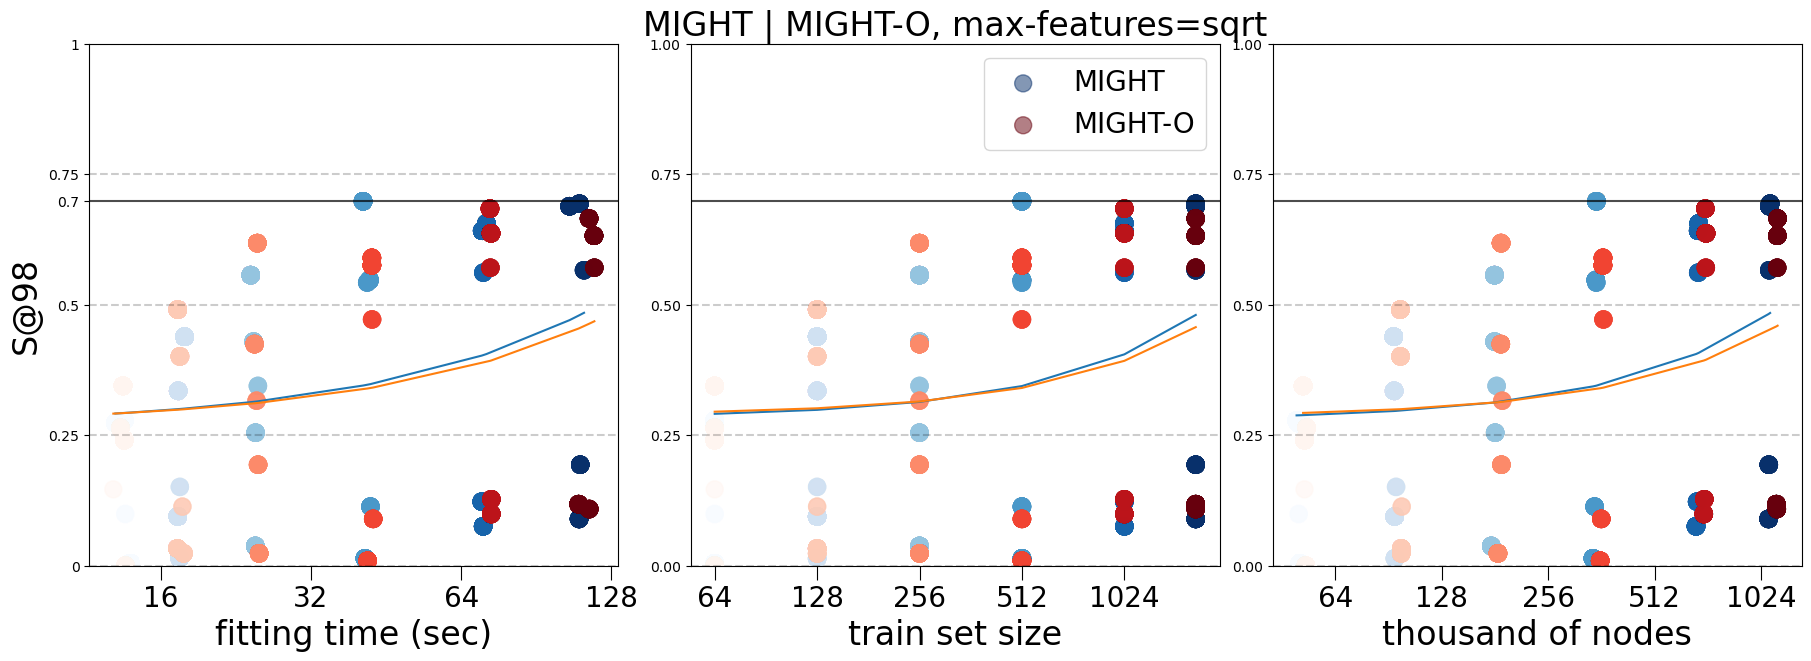

In [34]:
# plot the three in one plot
from matplotlib import scale
from matplotlib.pylab import f
from matplotlib.ticker import LogLocator, ScalarFormatter, FormatStrFormatter, FuncFormatter
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

MAX_FEAURES = "sqrt"
file_name = "test_stage1_by_cancer_type.csv"
# file_name = "results_both_sqrt.csv"
results_df = pd.read_csv(MODEL_DIR + file_name)
# covert he n_estimators to int
# impute the nan values with the mean of the column
# results_df = results_df.fillna(results_df.mean())
results_df["n_estimators"] = results_df["n_estimators"].astype(int)
# slice it to where n_estimators is 6000
# results_df = results_df[results_df["n_estimators"] == 6000]
# Slice the data to where max_features is 0.3
results_df = results_df[results_df["max_features"] == MAX_FEAURES]
# grab just the accuracy, subset_size, fit_time, num_nodes, n_estimator, and base_model
results_df = results_df[
    [
        "accuracy",
        "subset_size",
        "fit_time",
        "num_nodes",
        "n_estimators",
        "base_model",
        "s98",
        "s98_1",
        "max_features",
#         "s98_2",
#         "s98_3",
#         "s98_4",
    ]
]
models = results_df["base_model"].unique()
fig, axs = plt.subplots(1, 3, figsize=(18, 6.5), constrained_layout=True)
results_df["thou_nodes"] = results_df["num_nodes"] / 1000
x_metrics = ["fit_time", "subset_size", "thou_nodes"]
x_labels = ["fitting time (sec)", "train set size", "thousand of nodes"]
y_metrics = ["s98", "s98", "s98"]
x_mins = [
    np.min(results_df["fit_time"]),
    np.min(results_df["subset_size"]),
    np.min(results_df["thou_nodes"]),
]
x_maxs = [
    np.max(results_df["fit_time"]),
    np.max(results_df["subset_size"]),
    np.max(results_df["thou_nodes"]),
]
x_meds = [
    (np.max(results_df["fit_time"])-np.min(results_df["fit_time"]))/2,
    1024,
    (np.max(results_df["thou_nodes"])-np.min(results_df["thou_nodes"]))/2,
]
subset_sizes = results_df["subset_size"].unique()
x_ticks = [subset_sizes, [2**1, 2**4, 2**8, 2**10], [64, 2048, 5096, 10192]]
# add y_ticks at 0, 0.25, 0.5, 0.75, 1
y_ticks = [0, 0.25, 0.5, 0.75, 1]

# Create a colormap using viridis and sample it
blues = plt.get_cmap('Blues')
reds = plt.get_cmap('Reds')
# get another colormap other than viridis
colors = blues(np.linspace(0, 1, len(subset_sizes)))[::-1]
colors1 = reds(np.linspace(0, 1, len(subset_sizes)))[::-1]
# cmap = ListedColormap(colors)
# cmap1 = ListedColormap(colors1)

# Custom formatter to show real numbers
def log2_formatter(x, pos):
    return f'{int(x)}'

# Map the colors to the data
color_mapping = {val: colors[i] for i, val in enumerate(subset_sizes)}
color_mapping1 = {val: colors1[i] for i, val in enumerate(subset_sizes)}
results_df['color'] = results_df['subset_size'].map(color_mapping)
results_df['color1'] = results_df['subset_size'].map(color_mapping1)

for i, (x_metric, y_metric) in enumerate(zip(x_metrics, y_metrics)):
    axs[i].set_xlabel(x_metric)

    if i == 0:
        axs[i].set_ylabel("S@98", fontsize=24)
        axs[i].set_yticks(
            [0, 0.25, 0.5, np.max(results_df["s98"]), 0.75, 1],
            ["0", "0.25", "0.5", f'{round(np.max(results_df["s98"]), 2)}', "0.75","1"],
        )
    else:
        axs[i].set_yticks(y_ticks)

    axs[i].set_xlabel(x_labels[i], fontsize=24)
    
    axs[i].axhline(
        y=np.max(results_df["s98"]), color="black", linestyle="-", alpha=0.7
    )
    for y_tick in y_ticks:
        axs[i].axhline(
            y=y_tick, color="black", linestyle="--", alpha=0.2
        )
    # axs[i].tick_params(axis="y", labelsize=20)

#     axs[i].set_xticks([x_mins[i], x_meds[i], x_maxs[i]])

    axs[i].set_ylim([0, 1])
    # add y_ticks at 0, 0.25, 0.5, 0.75, 1


    axs[i].tick_params(axis="x", which="major", labelsize=20, length=10)
    # axs[i].tick_params(axis="x", which="minor", labelsize=20, length=8)
    # axs[i].xaxis.set_minor_locator(LogLocator(base=10, numticks=20))
    axs[i].xaxis.set_major_locator(LogLocator(base=2, numticks=4))
    axs[i].set_xscale("log", base=2)
    axs[i].xaxis.set_major_formatter(FuncFormatter(log2_formatter))
    # axs[i].set_xticks(x_ticks[i])
    #     axs[i].tick_params(axis="x", rotation=-90)
    #     axs[i].yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    #     axs[i].set_title(title)
    for model in models:
        df = results_df[results_df["base_model"] == model]
        # drop the base_model column
        df = df.drop("base_model", axis=1)
        #         df = df.groupby(x_metric).mean().reset_index()

        # axs[i].plot(df[x_metric], df[y_metric], label=model)
        if model == "DecisionTreeClassifier":
            model = "MIGHT"
            sc = axs[i].scatter(df[x_metric], df[y_metric], s=150, alpha=0.5, c=df['color'], label=model)
        else:
            model = "MIGHT-O"
            axs[i].scatter(df[x_metric], df[y_metric], s=150, alpha=0.5, c=df['color1'], label=model)
        # add regression line
        z = np.polyfit(df[x_metric], df[y_metric], 1)
        p = np.poly1d(z)
        axs[i].plot(sorted(df[x_metric].unique()), p(sorted(df[x_metric].unique())))

# add title
axs[1].set_title(f"MIGHT | MIGHT-O, max-features={MAX_FEAURES}", fontsize=24)
# Create a custom legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=f'{val}')
           for val, color in color_mapping.items()]
# add ledgend to denotes the model
axs[1].legend( fontsize=20)
# axs[i].legend(handles=handles, title='Subset Size')
# Add a color bar
# cbar = fig.colorbar(sc, ax=axs, orientation='vertical', fraction=0.02, pad=0.04)
# cbar.set_label('Subset Size', fontsize=14)

In [ ]:
# find the best model where the s98 is maximum
results_df.iloc[np.argmax(results_df["s98"])]

accuracy                                                 0.679487
subset_size                                                   512
fit_time                                                40.701526
num_nodes                                                  350290
n_estimators                                                 6000
base_model                                 DecisionTreeClassifier
s98                                                      0.698113
s98_1                                                    0.698113
max_features                                                 sqrt
thou_nodes                                                 350.29
color           [0.2909803921568628, 0.5945098039215686, 0.789...
color1          [0.9466666666666667, 0.26823529411764707, 0.19...
Name: 14, dtype: object

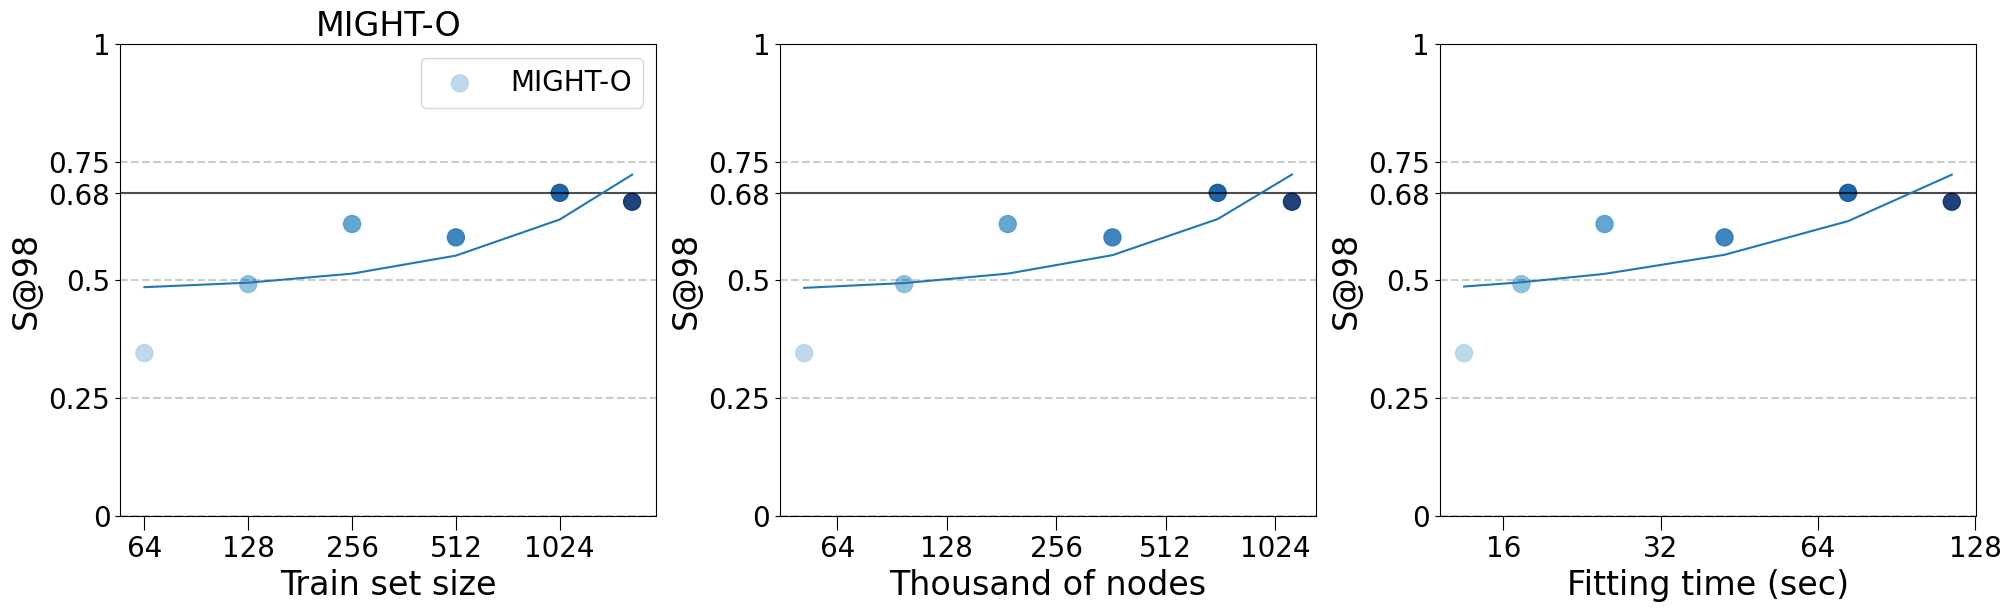

In [53]:
# make plot just for MIGHT-O on subset size on x-axis

MIGHTO_results = results_df[results_df["base_model"] == "ObliqueDecisionTreeClassifier"]
MIGHTO_results  = MIGHTO_results.groupby("subset_size").apply(
    lambda x: x.iloc[np.argmax(x["s98"])]
)
fig, axs = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
# add title
x_metrics = [ "subset_size", "thou_nodes", "fit_time",]
x_labels = [
    "Train set size",
    "Thousand of nodes",
    "Fitting time (sec)"
]
y_metrics = ["s98", "s98", "s98"]
x_mins = [
    np.min(MIGHTO_results["subset_size"]),
    np.min(MIGHTO_results["thou_nodes"]),
    np.min(MIGHTO_results["fit_time"]),
]
x_maxs = [
    np.max(MIGHTO_results["subset_size"]),
    np.max(MIGHTO_results["thou_nodes"]),
    np.max(MIGHTO_results["fit_time"]),
]
x_meds = [
    (np.max(MIGHTO_results["fit_time"]) - np.min(MIGHTO_results["fit_time"])) / 2,
    1024,
    (np.max(MIGHTO_results["thou_nodes"]) - np.min(MIGHTO_results["thou_nodes"])) / 2,
]
x_ticks = [[2**1, 2**4, 2**8, 2**10], subset_sizes, [64, 2048, 5096, 10192]]
# add y_ticks at 0, 0.25, 0.5, 0.75, 1
y_ticks = [0, 0.25, 0.5, 0.75, 1]
y_tick_labels = [
    "0",
    "0.25",
    "0.5",
    f'{round(np.max(MIGHTO_results["s98"]), 2)}',
    "0.75",
    "1",
]

# Create a colormap using viridis and sample it
blues = plt.get_cmap("Blues")
reds = plt.get_cmap("Reds")
# get another colormap other than viridis
colors = blues(np.linspace(0.30, 1, len(subset_sizes)))[::-1]
colors1 = reds(np.linspace(0.30, 1, len(subset_sizes)))[::-1]
# cmap = ListedColormap(colors)
# cmap1 = ListedColormap(colors1)


# Custom formatter to show real numbers
def log2_formatter(x, pos):
    return f"{int(x)}"


# Map the colors to the data
color_mapping = {val: colors[i] for i, val in enumerate(subset_sizes)}
color_mapping1 = {val: colors1[i] for i, val in enumerate(subset_sizes)}
MIGHTO_results["color"] = MIGHTO_results["subset_size"].map(color_mapping)
MIGHTO_results["color1"] = MIGHTO_results["subset_size"].map(color_mapping1)

for i, (x_metric, y_metric) in enumerate(zip(x_metrics, y_metrics)):
    axs[i].set_xlabel(x_metric)

    # if i == 0:
    axs[i].set_ylabel("S@98", fontsize=24)
    axs[i].set_yticks(
        [0, 0.25, 0.5, np.max(MIGHTO_results["s98"]), 0.75, 1],
        ["0", "0.25", "0.5", f'{round(np.max(MIGHTO_results["s98"]), 2)}', "0.75", "1"],
        fontsize=20,
    )
    # else:
    #     axs[i].set_yticks(y_ticks)
    #     axs[i].set_yticklabels(y_tick_labels, fontsize=20)

    axs[i].set_xlabel(x_labels[i], fontsize=24)

    axs[i].axhline(y=np.max(MIGHTO_results["s98"]), color="black", linestyle="-", alpha=0.7)
    for y_tick in y_ticks:
        axs[i].axhline(y=y_tick, color="black", linestyle="--", alpha=0.2)
    # axs[i].tick_params(axis="y", labelsize=20)

    #     axs[i].set_xticks([x_mins[i], x_meds[i], x_maxs[i]])

    axs[i].set_ylim([0, 1])
    # add y_ticks at 0, 0.25, 0.5, 0.75, 1

    axs[i].tick_params(axis="x", which="major", labelsize=20, length=10)
    # axs[i].tick_params(axis="x", which="minor", labelsize=20, length=8)
    # axs[i].xaxis.set_minor_locator(LogLocator(base=10, numticks=20))
    axs[i].xaxis.set_major_locator(LogLocator(base=2, numticks=4))
    axs[i].set_xscale("log", base=2)
    axs[i].xaxis.set_major_formatter(FuncFormatter(log2_formatter))
    # axs[i].set_xticks(x_ticks[i])
    #     axs[i].tick_params(axis="x", rotation=-90)
    #     axs[i].yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    #     axs[i].set_title(title)
    for model in models:
        df = MIGHTO_results[MIGHTO_results["base_model"] == model]
        # drop the base_model column
        df = df.drop("base_model", axis=1)
        #         df = df.groupby(x_metric).mean().reset_index()

        # axs[i].plot(df[x_metric], df[y_metric], label=model)
        if model == "DecisionTreeClassifier":
            continue
            # model = "MIGHT"
            # sc = axs[i].scatter(
            #     df[x_metric], df[y_metric], s=150, alpha=0.5, c=df["color"], label=model
            # )
        else:
            model = "MIGHT-O"
            axs[i].scatter(
                df[x_metric],
                df[y_metric],
                s=150,
                alpha=0.9,
                c=df["color"],
                label=model,
            )
        # add regression line
        z = np.polyfit(df[x_metric], df[y_metric], 1)
        p = np.poly1d(z)
        axs[i].plot(sorted(df[x_metric].unique()), p(sorted(df[x_metric].unique())))

# add title
axs[0].set_title(
    f"MIGHT-O", fontsize=24
)
# Create a custom legend
handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=color,
        markersize=10,
        label=f"{val}",
    )
    for val, color in color_mapping.items()
]
# add ledgend to denotes the model
axs[0].legend(fontsize=20)
# axs[i].legend(handles=handles, title='Subset Size')
# Add a color bar
# cbar = fig.colorbar(sc, ax=axs, orientation='vertical', fraction=0.02, pad=0.04)
# cbar.set_label('Subset Size', fontsize=14)

In [49]:
# find the best model where the s98 is maximum for each subset size
MIGHTO_results.groupby("subset_size").apply(lambda x: x.iloc[np.argmax(x["s98"])])

,accuracy,subset_size,fit_time,num_nodes,n_estimators,base_model,s98,s98_1,max_features,thou_nodes,color,color1
subset_size,,,,,,,,,,,,
64,0.679487,64,13.449749,51910,6000,ObliqueDecisionTreeClassifier,0.344340,0.344340,sqrt,51.910,"[0.9686274509803922, 0.984313725490196, 1.0, 1.0]","[1.0, 0.9607843137254902, 0.9411764705882353, ..."
128,0.679487,128,17.314865,97774,6000,ObliqueDecisionTreeClassifier,0.490566,0.490566,sqrt,97.774,"[0.8141176470588235, 0.883921568627451, 0.9498...","[0.9913725490196079, 0.7913725490196079, 0.708..."
256,0.679487,256,24.987688,188328,6000,ObliqueDecisionTreeClassifier,0.617925,0.617925,sqrt,188.328,"[0.5796078431372549, 0.7701960784313725, 0.873...","[0.9874509803921568, 0.5411764705882353, 0.415..."
512,0.679487,512,42.393520,365590,6000,ObliqueDecisionTreeClassifier,0.589623,0.589623,sqrt,365.590,"[0.2909803921568628, 0.5945098039215686, 0.789...","[0.9466666666666667, 0.26823529411764707, 0.19..."
1024,0.679487,1024,73.084562,711698,6000,ObliqueDecisionTreeClassifier,0.683962,0.683962,sqrt,711.698,"[0.09019607843137256, 0.39294117647058824, 0.6...","[0.7364705882352941, 0.08, 0.10117647058823528..."
1660,0.679487,1660,115.423538,1139108,6000,ObliqueDecisionTreeClassifier,0.665094,0.665094,sqrt,1139.108,"[0.03137254901960784, 0.18823529411764706, 0.4...","[0.403921568627451, 0.0, 0.05098039215686274, ..."


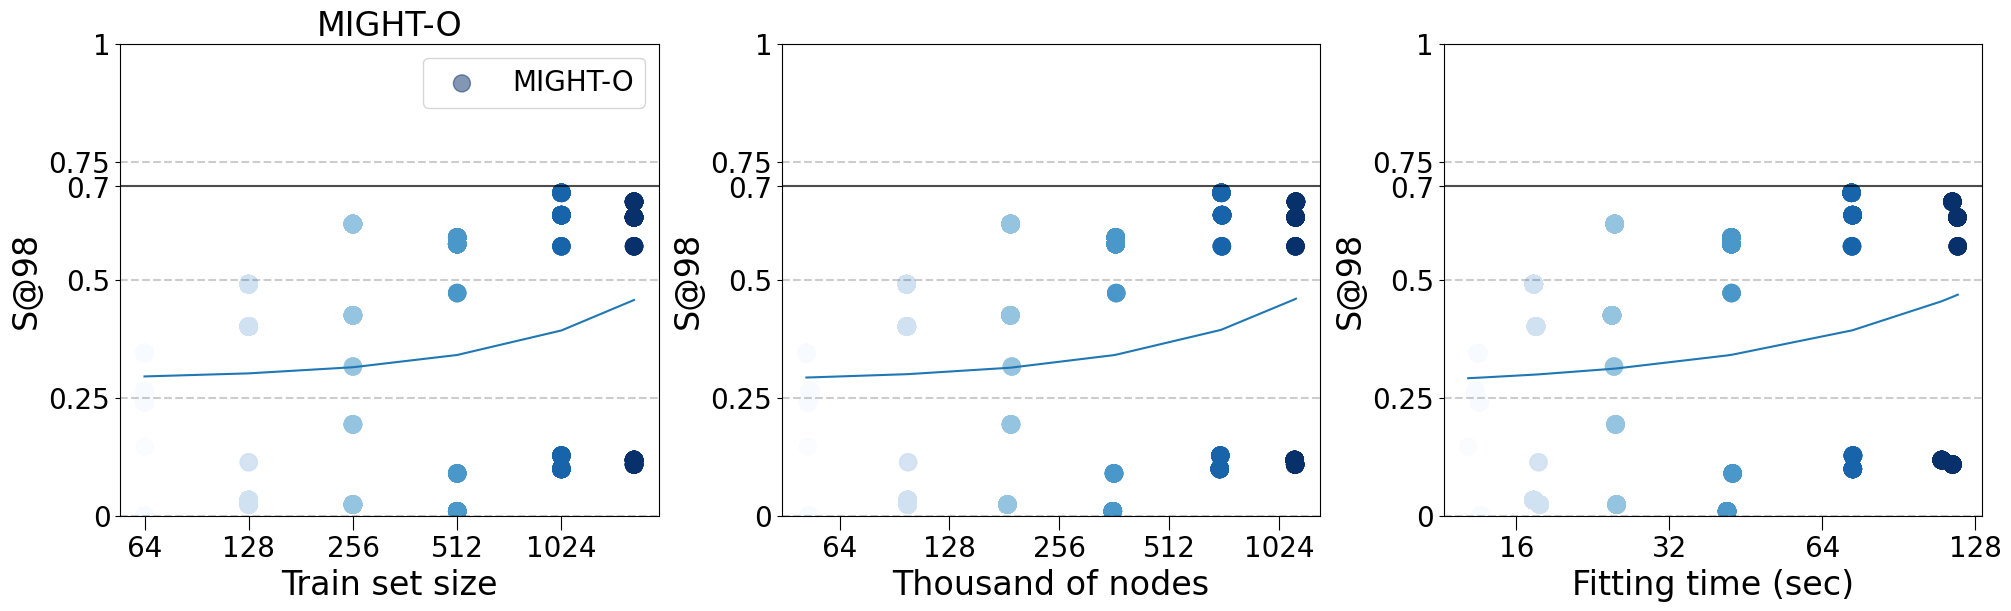

In [ ]:
# make plot just for MIGHT-O on subset size on x-axis

MIGHTO_results = results_df[results_df["base_model"] == "ObliqueDecisionTreeClassifier"]
fig, axs = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
# add title
x_metrics = [ "subset_size", "thou_nodes", "fit_time",]
x_labels = [
    "Train set size",
    "Thousand of nodes",
    "Fitting time (sec)"
]
y_metrics = ["s98", "s98", "s98"]
x_mins = [
    np.min(MIGHTO_results["subset_size"]),
    np.min(MIGHTO_results["thou_nodes"]),
    np.min(MIGHTO_results["fit_time"]),
]
x_maxs = [
    np.max(MIGHTO_results["subset_size"]),
    np.max(MIGHTO_results["thou_nodes"]),
    np.max(MIGHTO_results["fit_time"]),
]
x_meds = [
    (np.max(MIGHTO_results["fit_time"]) - np.min(MIGHTO_results["fit_time"])) / 2,
    1024,
    (np.max(MIGHTO_results["thou_nodes"]) - np.min(MIGHTO_results["thou_nodes"])) / 2,
]
x_ticks = [[2**1, 2**4, 2**8, 2**10], subset_sizes, [64, 2048, 5096, 10192]]
# add y_ticks at 0, 0.25, 0.5, 0.75, 1
y_ticks = [0, 0.25, 0.5, 0.75, 1]
y_tick_labels = [
    "0",
    "0.25",
    "0.5",
    f'{round(np.max(MIGHTO_results["s98"]), 2)}',
    "0.75",
    "1",
]

# Create a colormap using viridis and sample it
blues = plt.get_cmap("Blues")
reds = plt.get_cmap("Reds")
# get another colormap other than viridis
colors = blues(np.linspace(0, 1, len(subset_sizes)))[::-1]
colors1 = reds(np.linspace(0, 1, len(subset_sizes)))[::-1]
# cmap = ListedColormap(colors)
# cmap1 = ListedColormap(colors1)

# Custom formatter to show real numbers
def log2_formatter(x, pos):
    return f"{int(x)}"


# Map the colors to the data
color_mapping = {val: colors[i] for i, val in enumerate(subset_sizes)}
color_mapping1 = {val: colors1[i] for i, val in enumerate(subset_sizes)}
results_df["color"] = results_df["subset_size"].map(color_mapping)
results_df["color1"] = results_df["subset_size"].map(color_mapping1)

for i, (x_metric, y_metric) in enumerate(zip(x_metrics, y_metrics)):
    axs[i].set_xlabel(x_metric)

    # if i == 0:
    axs[i].set_ylabel("S@98", fontsize=24)
    axs[i].set_yticks(
        [0, 0.25, 0.5, np.max(results_df["s98"]), 0.75, 1],
        ["0", "0.25", "0.5", f'{round(np.max(results_df["s98"]), 2)}', "0.75", "1"],
        fontsize=20,
    )
    # else:
    #     axs[i].set_yticks(y_ticks)
    #     axs[i].set_yticklabels(y_tick_labels, fontsize=20)

    axs[i].set_xlabel(x_labels[i], fontsize=24)

    axs[i].axhline(y=np.max(results_df["s98"]), color="black", linestyle="-", alpha=0.7)
    for y_tick in y_ticks:
        axs[i].axhline(y=y_tick, color="black", linestyle="--", alpha=0.2)
    # axs[i].tick_params(axis="y", labelsize=20)

    #     axs[i].set_xticks([x_mins[i], x_meds[i], x_maxs[i]])

    axs[i].set_ylim([0, 1])
    # add y_ticks at 0, 0.25, 0.5, 0.75, 1

    axs[i].tick_params(axis="x", which="major", labelsize=20, length=10)
    # axs[i].tick_params(axis="x", which="minor", labelsize=20, length=8)
    # axs[i].xaxis.set_minor_locator(LogLocator(base=10, numticks=20))
    axs[i].xaxis.set_major_locator(LogLocator(base=2, numticks=4))
    axs[i].set_xscale("log", base=2)
    axs[i].xaxis.set_major_formatter(FuncFormatter(log2_formatter))
    # axs[i].set_xticks(x_ticks[i])
    #     axs[i].tick_params(axis="x", rotation=-90)
    #     axs[i].yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    #     axs[i].set_title(title)
    for model in models:
        df = results_df[results_df["base_model"] == model]
        # drop the base_model column
        df = df.drop("base_model", axis=1)
        #         df = df.groupby(x_metric).mean().reset_index()

        # axs[i].plot(df[x_metric], df[y_metric], label=model)
        if model == "DecisionTreeClassifier":
            continue
            # model = "MIGHT"
            # sc = axs[i].scatter(
            #     df[x_metric], df[y_metric], s=150, alpha=0.5, c=df["color"], label=model
            # )
        else:
            model = "MIGHT-O"
            axs[i].scatter(
                df[x_metric],
                df[y_metric],
                s=150,
                alpha=0.5,
                c=df["color"],
                label=model,
            )
        # add regression line
        z = np.polyfit(df[x_metric], df[y_metric], 1)
        p = np.poly1d(z)
        axs[i].plot(sorted(df[x_metric].unique()), p(sorted(df[x_metric].unique())))

# add title
axs[0].set_title(
    f"MIGHT-O", fontsize=24
)
# Create a custom legend
handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=color,
        markersize=10,
        label=f"{val}",
    )
    for val, color in color_mapping.items()
]
# add ledgend to denotes the model
axs[0].legend(fontsize=20)
# axs[i].legend(handles=handles, title='Subset Size')
# Add a color bar
# cbar = fig.colorbar(sc, ax=axs, orientation='vertical', fraction=0.02, pad=0.04)
# cbar.set_label('Subset Size', fontsize=14)

array([[0.03137255, 0.18823529, 0.41960784, 1.        ],
       [0.09019608, 0.39294118, 0.67058824, 1.        ],
       [0.29098039, 0.5945098 , 0.78901961, 1.        ],
       [0.57960784, 0.77019608, 0.87372549, 1.        ],
       [0.81411765, 0.88392157, 0.94980392, 1.        ],
       [0.96862745, 0.98431373, 1.        , 1.        ]])

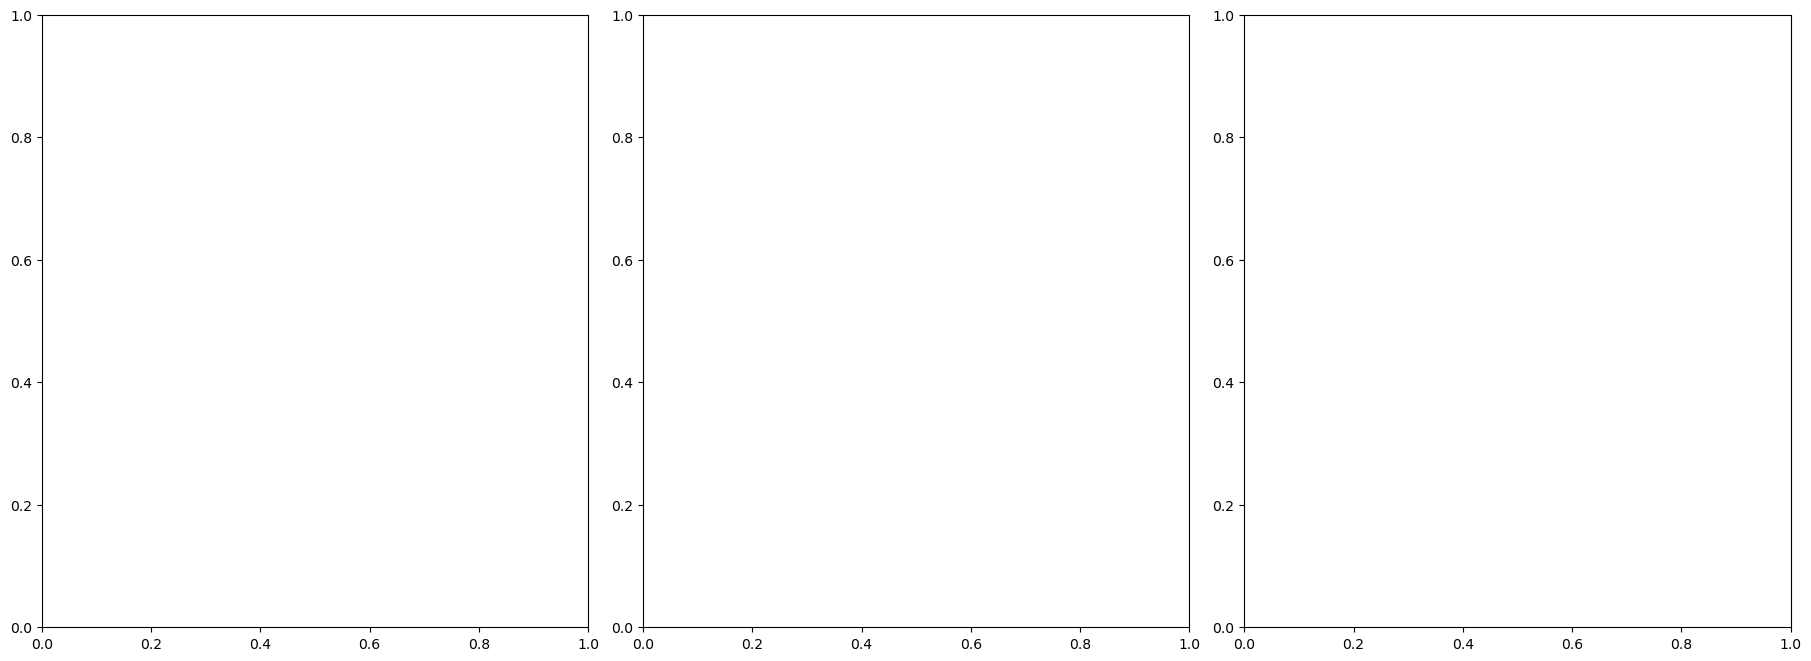

In [ ]:
# plot the three in one plot
from matplotlib import scale
from matplotlib.pylab import f
from matplotlib.ticker import LogLocator, ScalarFormatter, FormatStrFormatter, FuncFormatter
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

MAX_FEAURES = "sqrt"
file_name = "results_max_features.csv"
# file_name = "results_both_sqrt.csv"
results_df = pd.read_csv(MODEL_DIR + file_name)
# covert he n_estimators to int
# impute the nan values with the mean of the column
# results_df = results_df.fillna(results_df.mean())
results_df["n_estimators"] = results_df["n_estimators"].astype(int)
# slice it to where n_estimators is 6000
# results_df = results_df[results_df["n_estimators"] == 6000]
# grab just the accuracy, subset_size, fit_time, num_nodes, n_estimator, and base_model
results_df = results_df[
    [
        "accuracy",
        "subset_size",
        "fit_time",
        "num_nodes",
        "n_estimators",
        "base_model",
        "s98",
        "s98_1",
        "max_features",
#         "s98_2",
#         "s98_3",
#         "s98_4",
    ]
]
models = results_df["base_model"].unique()
fig, axs = plt.subplots(1, 3, figsize=(18, 6.5), constrained_layout=True)
results_df["thou_nodes"] = results_df["num_nodes"] / 1000
x_metrics = ["fit_time", "subset_size", "thou_nodes"]
x_labels = ["fitting time (sec)", "train set size", "thousand of nodes"]
y_metrics = ["s98", "s98", "s98"]
x_mins = [
    np.min(results_df["fit_time"]),
    np.min(results_df["subset_size"]),
    np.min(results_df["thou_nodes"]),
]
x_maxs = [
    np.max(results_df["fit_time"]),
    np.max(results_df["subset_size"]),
    np.max(results_df["thou_nodes"]),
]
x_meds = [
    (np.max(results_df["fit_time"])-np.min(results_df["fit_time"]))/2,
    1024,
    (np.max(results_df["thou_nodes"])-np.min(results_df["thou_nodes"]))/2,
]
x_ticks = [[2**1, 2**4, 2**8, 2**10],subset_sizes,[64, 2048, 5096, 10192]]

# Create a colormap using viridis and sample it
blues = plt.get_cmap('Blues')
reds = plt.get_cmap('Reds')
# get another colormap other than viridis
colors = blues(np.linspace(0, 1, len(subset_sizes)))[::-1]
colors1 = reds(np.linspace(0, 1, len(subset_sizes)))[::-1]

# Custom formatter to show real numbers
def log2_formatter(x, pos):
    return f'{int(x)}'

# Map the colors to the data
color_mapping = {val: colors[i] for i, val in enumerate(subset_sizes)}
color_mapping1 = {val: colors1[i] for i, val in enumerate(subset_sizes)}
results_df['color'] = results_df['subset_size'].map(color_mapping)
results_df['color1'] = results_df['subset_size'].map(color_mapping1)

for i, (x_metric, y_metric) in enumerate(zip(x_metrics, y_metrics)):
    axs[i].set_xlabel(x_metric)

    if i == 0:
        axs[i].set_ylabel("S@98", fontsize=24)
        axs[i].set_yticks(
            [0, 0.25, 0.5, np.max(results_df["s98"]), 0.75, 1],
            ["0", "0.25", "0.5", f'{round(np.max(results_df["s98"]), 2)}', "0.75","1"],
        )
    else:
        axs[i].set_yticks(y_ticks)

    axs[i].set_xlabel(x_labels[i], fontsize=24)
    
    axs[i].axhline(
        y=np.max(results_df["s98"]), color="black", linestyle="--", alpha=0.7
    )
    axs[i].tick_params(axis="y", labelsize=20)
#     axs[i].set_xticks([x_mins[i], x_meds[i], x_maxs[i]])

    axs[i].set_ylim([0, 1])

    axs[i].tick_params(axis="x", which="major", labelsize=20, length=10)
    # axs[i].tick_params(axis="x", which="minor", labelsize=20, length=8)
    # axs[i].xaxis.set_minor_locator(LogLocator(base=10, numticks=20))
    axs[i].xaxis.set_major_locator(LogLocator(base=2, numticks=4))
    axs[i].set_xscale("log", base=2)
    axs[i].xaxis.set_major_formatter(FuncFormatter(log2_formatter))
    # axs[i].set_xticks(x_ticks[i])
    #     axs[i].tick_params(axis="x", rotation=-90)
    #     axs[i].yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    #     axs[i].set_title(title)
    # Slice the data to where max_features is 0.3
    results_df = results_df[results_df["max_features"] == MAX_FEAURES]
    for model in models:
        df = results_df[results_df["base_model"] == model]
        # drop the base_model column
        df = df.drop("base_model", axis=1)
        #         df = df.groupby(x_metric).mean().reset_index()

        # axs[i].plot(df[x_metric], df[y_metric], label=model)
        if model == "DecisionTreeClassifier":
            model = "MIGHT"
            sc = axs[i].scatter(df[x_metric], df[y_metric], s=150, alpha=0.5, c=df['color'], label=model)
        else:
            model = "MIGHT-O"
            axs[i].scatter(df[x_metric], df[y_metric], s=150, alpha=0.5, c=df['color1'], label=model)
        # add regression line
        z = np.polyfit(df[x_metric], df[y_metric], 1)
        p = np.poly1d(z)
        axs[i].plot(sorted(df[x_metric].unique()), p(sorted(df[x_metric].unique())))

# add title
# calculate the proprtion of max_features 
p_features = np.sqrt(X_test.shape[1])/X_test.shape[1]
axs[1].set_title(f"MIGHT | MIGHT-O {n_est} Trees, max-features={MAX_FEAURES}~{np.round(p_features,3)}", fontsize=24)
# Create a custom legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=f'{val}')
           for val, color in color_mapping.items()]
# add ledgend to denotes the model
axs[1].legend( fontsize=20)
# axs[i].legend(handles=handles, title='Subset Size')
# Add a color bar
# cbar = fig.colorbar(sc, ax=axs, orientation='vertical', fraction=0.02, pad=0.04)
# cbar.set_label('Subset Size', fontsize=14)


In [ ]:
# # plot the three in one plot
# from matplotlib import scale
# from matplotlib.ticker import LogLocator, ScalarFormatter

# fig, axs = plt.subplots(4, 3, figsize=(18, 24))
# x_metrics = ["fit_time", "subset_size", "num_nodes"]
# # y_metrics = ["s98", "s98", "s98"]
# y_metrics = ["s98", "s98", "s98"]
# titles = ["S98 vs fit_time (sec)", "S98 vs Subset size", "S98 vs Num nodes"]
# for j in range(4):
#     for i, (x_metric, y_metric, title) in enumerate(zip(x_metrics, y_metrics, titles)):
#         y_metric = f"s98_{j+1}"
#         axs[j, i].set_xlabel(x_metric)
#         # # set the xticks to log scale
#         axs[j, i].xaxis.set_major_locator(LogLocator(base=2.0, numticks=10))
#         axs[j, i].set_ylabel("S98")
#         axs[j, i].yaxis.set_major_formatter(ScalarFormatter(1)) 
#         # set all the y-axis to be the same
#         axs[j, i].set_ylim(0.0, 1)
#         axs[j, i].set_title(f" Stage {j+1}: "+title )
#         for model in models:
#             df = results_df[results_df["base_model"] == model]
#             # drop the base_model column
#             df = df.drop("base_model", axis=1)
#             df = df.groupby(x_metric).mean().reset_index()

#             # axs[i].plot(df[x_metric], df[y_metric], label=model)
#             axs[j, i].scatter(df[x_metric], df[y_metric], label=model)
#             # add regression line
#             z = np.polyfit(df[x_metric], df[y_metric], 1)
#             p = np.poly1d(z)
#             axs[j, i].plot(df[x_metric], p(df[x_metric]), label=model)
        
# axs[j, i].legend() 

In [88]:
results_df = pd.read_csv(MODEL_DIR + file_name)
results_df.head()

,dataset,cohort,subset_size,n_estimators,n_jobs,random_state,base_model,fit_time,num_nodes,s98_1,s98_2,s98_3,s98_4,s98,accuracy,roc_auc,f1,precision,recall
0,WiseCondorX.Wise-1.csv,NaN,1922,100,50,691,RandomForestClassifier,5.828636,21050,0.125,0.666667,0.888889,0.75,0.606061,0.80,0.734403,0.861111,0.794872,0.939394
1,WiseCondorX.Wise-1.csv,NaN,1922,100,50,691,RandomForestClassifier,5.828636,21050,0.125,0.666667,0.888889,0.75,0.606061,0.80,0.734403,0.861111,0.794872,0.939394
2,WiseCondorX.Wise-1.csv,NaN,1922,100,50,691,ObliqueRandomForestClassifier,19.055306,21872,0.500,0.833333,1.000000,0.75,0.787879,0.82,0.778075,0.869565,0.833333,0.909091
3,WiseCondorX.Wise-1.csv,NaN,1922,100,50,691,RandomForestClassifier,5.828636,21050,0.125,0.666667,0.888889,0.75,0.606061,0.80,0.734403,0.861111,0.794872,0.939394
4,WiseCondorX.Wise-1.csv,NaN,1922,100,50,691,ObliqueRandomForestClassifier,19.055306,21872,0.500,0.833333,1.000000,0.75,0.787879,0.82,0.778075,0.869565,0.833333,0.909091


In [57]:

MODEL_DIR = "./trained_models/"
N_JOBS = 50
N_EST = 100 # 100_000
RANDOM_STATE = np.random.randint(1000)
TEST_SIZE = 50
REPEATS = 10
STAGE = True
RESULTS_FILE = f"results_{N_EST}EST_{REPEATS}REP.csv"

# obtain the samples for cohort 1 and cohort 2
X, y = get_X_y("WiseCondorX.Wise-1.csv", root=DIRECTORY, cohort=None, stage=True)
print(X.shape, y.shape)

# get a basic stats of the data
subset_sizes = [2**i for i in range(5, 11)]

if X.shape[0] - TEST_SIZE >= subset_sizes[-1]:
    subset_sizes.append(X.shape[0] - TEST_SIZE)

print("subset_sizes: ", subset_sizes[::-1])

RF = RandomForestClassifier(n_estimators=N_EST, max_features=0.3, n_jobs=N_JOBS, random_state=RANDOM_STATE)
SPORF = ObliqueRandomForestClassifier(n_estimators=N_EST, max_features=0.3, n_jobs=N_JOBS, random_state=RANDOM_STATE)

# MODELS = [RF, SPORF]
# MODELS = [RF]
MODELS = [SPORF]



# define a dictionary to store the results
results = defaultdict(list)

for i in range(REPEATS):
    # shuffle the data
    # obtain the samples for cohort 1 and cohort 2
    X, y = get_X_y("WiseCondorX.Wise-1.csv", root=DIRECTORY, cohort=None, stage=True)
    X, y = X.sample(frac=1, random_state=RANDOM_STATE), y.sample(frac=1, random_state=RANDOM_STATE)
    for subset_size in subset_sizes[3:4]:
        RANDOM_STATE +=1
        # get the subset of the data
        class_feaure = np.array(y)[:,0].astype(int) if not STAGE else np.array(y)[:,1].astype(int)
        # try to get the stratified subset until it has both classes
        if TEST_SIZE + subset_size > X.shape[0]:
            # print("Subset size is greater than the data size")
            continue
        print("X shape: ", X.shape)
        X_sub, X_test, y_sub, y_test = train_test_split(X, y, train_size=subset_size, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=class_feaure)
        print("X_sub shape: ", X_sub.shape)
        # check if the subset has the both classes
        # while len(np.unique(y_sub)) < 2 or np.unique(y_sub, return_counts=True)[1].min() < 3:
        #     RANDOM_STATE += 1
        #     X_sub, _, y_sub, _ = train_test_split(X, y, train_size=subset_size, random_state=RANDOM_STATE)
        if y_sub.squeeze().ndim != 1:
            # set the STAGE parameter to True
            STAGE = True
            y_sub_label = np.array(y_sub)[:,0].astype(int)
            y_sub_stages = np.array(y_sub)[:,1].astype(str)
        # check the class distribution
        print(f"Subset size: {subset_size}, Class distribution: {np.unique(y_sub_label, return_counts=True)}")

        # fit the models
        for est in MODELS:
            base_model = est.__class__.__name__ #if est.tree_estimator is not None else "DescisionTreeClassifier"
            kwargs = {}
            kwargs["dataset"] = "WiseCondorX.Wise-1.csv"
            kwargs["cohort"] = "None"
            kwargs["subset_size"] = subset_size
            kwargs["n_estimators"] = N_EST
            kwargs["n_jobs"] = N_JOBS
            kwargs["random_state"] = RANDOM_STATE
            kwargs["base_model"] = base_model
            # start time
            start_time = time.perf_counter()
            # obtain tree level posteriors
#             fitted_est, tree_proba = build_oob_forest(est, X_sub, y_sub)
            est.fit(X_sub, y_sub_label)
            # calculate fitting time
            end_time = time.perf_counter()
            time_dif = end_time-start_time
            kwargs["fit_time"] = time_dif
            print(f"Subset size: {subset_size}, Model: {base_model}, Time: {time_dif}")
            # get the posterior probabilities
            posterior = est.predict_proba(X_test)
            # get the metrics and log the results
            y_pred = np.argmax(posterior, axis=1)
            # count the number of nodes
            num_nodes = node_count(est, forest=True)
            kwargs["num_nodes"] = num_nodes
            y_test_label = np.array(y_test)[:,0].astype(int) if STAGE else y_test
            y_test_stage = np.array(y_test)[:,1] if STAGE else None
            s98 = Calculate_SA(np.array(y_test_label), np.array(posterior), max_fpr=0.02)
            if STAGE:
                # calculate the metric for each stage
                # subset the Normal samples
                y_test_0 = y_test_label[y_test_label == 0]
                y_pred_0 = y_pred[y_test_label == 0]
                posterior_0 = posterior[y_test_label == 0]
                for stage in [1, 2, 3, 4]:
                    idx = y_test_stage == stage
                    y_test_label_stage = y_test_label[idx] if len(y_test_label[idx]) > 0 else []
                    y_pred_stage = y_pred[idx] if len(y_pred[idx]) > 0 else []
                    posterior_stage = posterior[idx] if len(posterior[idx]) > 0 else []
                    # print(y_test_label_stage, y_pred_stage, posterior_stage)
                    # concatenate the y_test_0 and y_test_label_stage
                    y_test_label_stage_ = np.concatenate([y_test_0, y_test_label_stage])
                    posterior_stage_ = np.concatenate([posterior_0, posterior_stage])
                    s98_stage = Calculate_SA(np.array(y_test_label_stage_), np.array(posterior_stage_), max_fpr=0.02)
                    print(f"Subset size: {subset_size}, Model: {base_model}, Stage: {stage}, s98: {s98_stage}")
                    # store the results for each stage
                    kwargs[f"s98_{stage}"] = s98_stage
            print(f"Subset size: {subset_size}, Model: {base_model}, s98: {s98}")
            kwargs["s98"] = s98
            log_results(results, y_test_label, y_pred, **kwargs)
            # save the results
            results_df = pd.DataFrame(results)
            # # check if the file exists and append the results
            # file_name = RESULTS_FILE
            # # check if the file exists
            # if file_name not in os.listdir(MODEL_DIR):
            #     results_df.to_csv(MODEL_DIR + file_name, index=False)
            # else:
            #     # check if it has the same columns
            #     if not all(results_df.columns == pd.read_csv(MODEL_DIR + file_name).columns):
            #         print("Columns do not match")
            #         # save the results
            #         results_df.to_csv(MODEL_DIR + file_name, index=False)
            #     results_df.to_csv(MODEL_DIR + file_name, index=False, mode='a', header=False)
            # print("Results saved")
        # replace the X, y with the subset
        X, y = X_sub, y_sub
        # save the model
        # model_name = f"{base_model}_{subset_size}_samples_{N_EST}_n_est.pkl"
        # with open(MODEL_DIR + model_name, "wb", ) as f:
        #     pickle.dump(est, f)
        # print(f"Model saved: {model_name}")



(1972, 2523) (1972, 2)
subset_sizes:  [1922, 1024, 512, 256, 128, 64, 32]
X shape:  (1972, 2523)
X_sub shape:  (256, 2523)
Subset size: 256, Class distribution: (array([0, 1]), array([ 88, 168]))
Subset size: 256, Model: ObliqueRandomForestClassifier, Time: 2.585106166996411
Subset size: 256, Model: ObliqueRandomForestClassifier, Stage: 1, s98: 0.25
Subset size: 256, Model: ObliqueRandomForestClassifier, Stage: 2, s98: 0.5
Subset size: 256, Model: ObliqueRandomForestClassifier, Stage: 3, s98: 0.7777777777777778
Subset size: 256, Model: ObliqueRandomForestClassifier, Stage: 4, s98: 0.75
Subset size: 256, Model: ObliqueRandomForestClassifier, s98: 0.5454545454545454
X shape:  (1972, 2523)
X_sub shape:  (256, 2523)
Subset size: 256, Class distribution: (array([0, 1]), array([ 88, 168]))
Subset size: 256, Model: ObliqueRandomForestClassifier, Time: 2.6047212920093443
Subset size: 256, Model: ObliqueRandomForestClassifier, Stage: 1, s98: 0.25
Subset size: 256, Model: ObliqueRandomForestClas

In [58]:
# grab just the accuracy, subset_size, fit_time, num_nodes, n_estimator, and base_model
results_df = results_df[["accuracy", "subset_size", "fit_time", "num_nodes", "n_estimators", "base_model", "s98"]]
models = results_df["base_model"].unique()
results_df.head()

,accuracy,subset_size,fit_time,num_nodes,n_estimators,base_model,s98
0,0.70,256,2.585106,3286,100,ObliqueRandomForestClassifier,0.545455
1,0.72,256,2.604721,3330,100,ObliqueRandomForestClassifier,0.545455
2,0.76,256,2.636977,3250,100,ObliqueRandomForestClassifier,0.454545
3,0.78,256,2.622483,3354,100,ObliqueRandomForestClassifier,0.242424
4,0.76,256,2.573161,3224,100,ObliqueRandomForestClassifier,0.333333


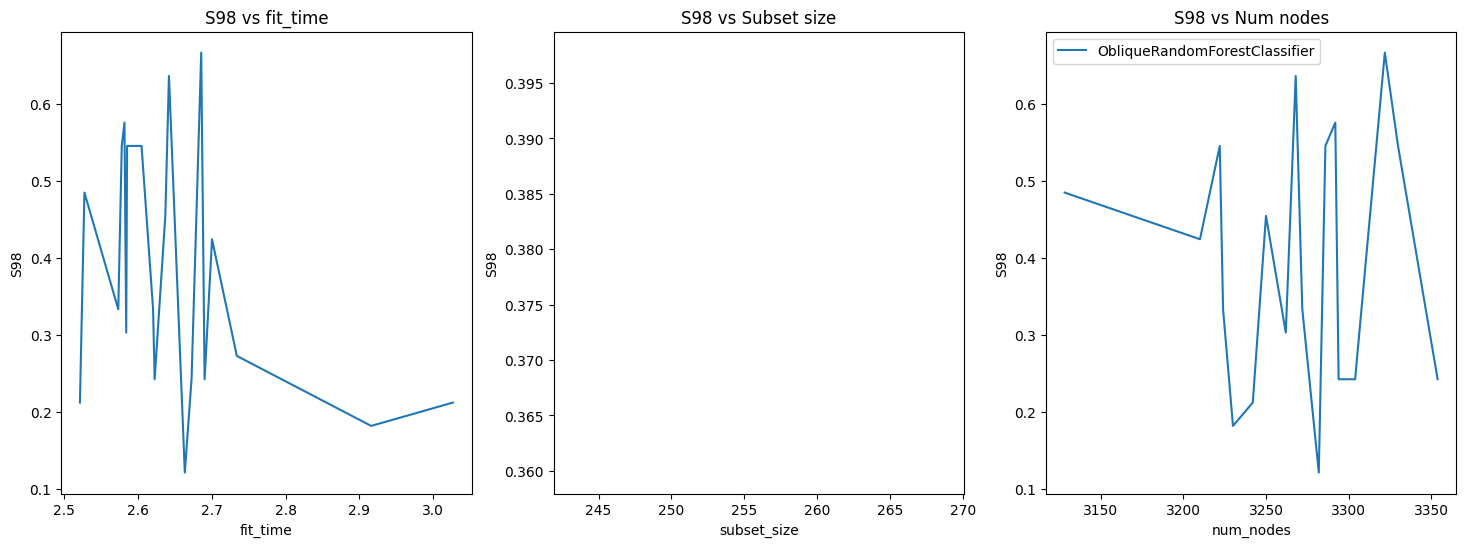

In [62]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
x_metrics = ["fit_time", "subset_size", "num_nodes"]
y_metrics = ["s98", "s98", "s98"]
titles = ["S98 vs fit_time", "S98 vs Subset size", "S98 vs Num nodes"]
for i, (x_metric, y_metric, title) in enumerate(zip(x_metrics, y_metrics, titles)):
    axs[i].set_xlabel(x_metric)
    axs[i].set_ylabel("S98")
    axs[i].yaxis.set_major_formatter(ScalarFormatter(1)) 
    axs[i].set_title(title)
    for model in models:
        df = results_df[results_df["base_model"] == model]
        # drop the base_model column
        df = df.drop("base_model", axis=1)
        df = df.groupby(x_metric).mean().reset_index()

        axs[i].plot(df[x_metric], df[y_metric], label=model)
axs[i].legend() 

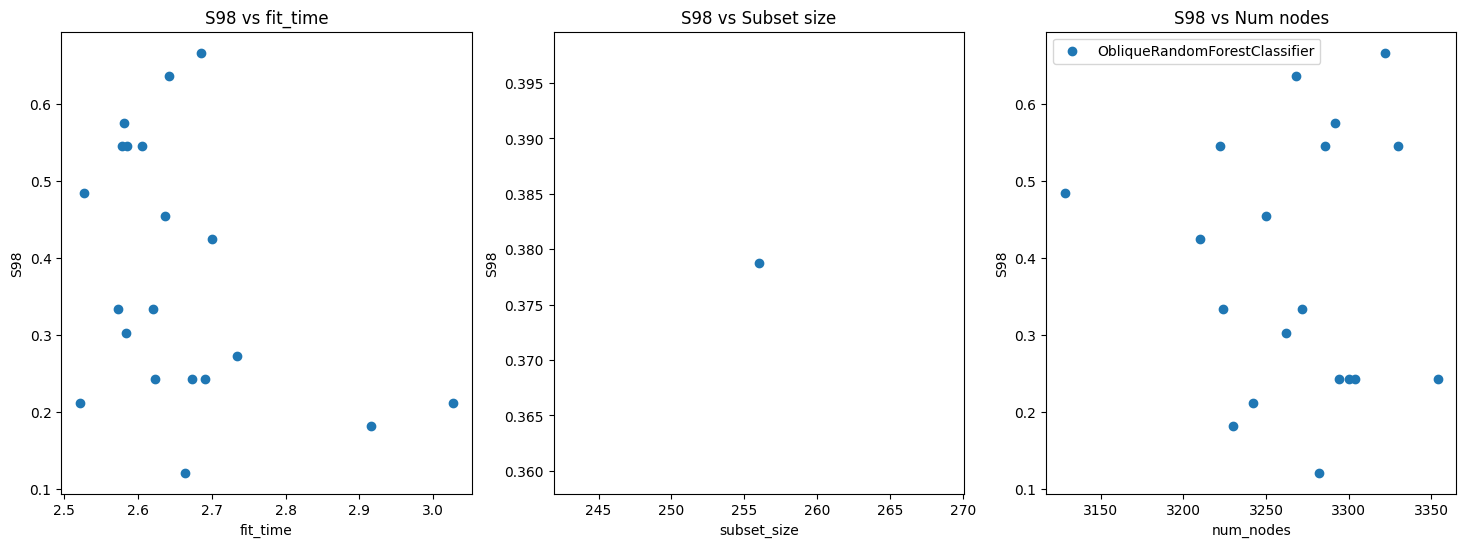

In [63]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
x_metrics = ["fit_time", "subset_size", "num_nodes"]
y_metrics = ["s98", "s98", "s98"]
titles = ["S98 vs fit_time", "S98 vs Subset size", "S98 vs Num nodes"]
for i, (x_metric, y_metric, title) in enumerate(zip(x_metrics, y_metrics, titles)):
    axs[i].set_xlabel(x_metric)
    axs[i].set_ylabel("S98")
    axs[i].yaxis.set_major_formatter(ScalarFormatter(1)) 
    axs[i].set_title(title)
    for model in models:
        df = results_df[results_df["base_model"] == model]
        # drop the base_model column
        df = df.drop("base_model", axis=1)
        df = df.groupby(x_metric).mean().reset_index()

        # axs[i].plot(df[x_metric], df[y_metric], label=model)
        axs[i].scatter(df[x_metric], df[y_metric], label=model)
axs[i].legend() 

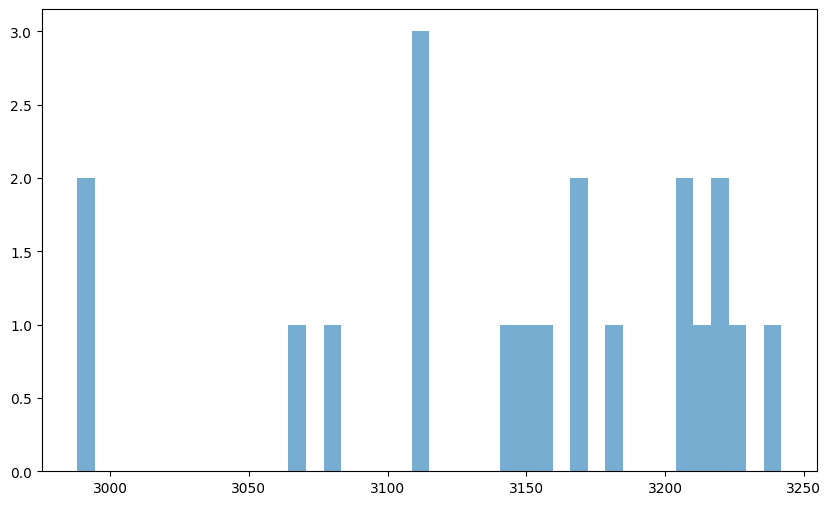

In [56]:
# plot histgram of fit_time
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
for model in models:
    df = results_df[results_df["base_model"] == model]
    ax.hist(df["num_nodes"], bins=40, alpha=0.6, label=model)

In [134]:
from sre_constants import REPEAT
from tabnanny import verbose
import pandas as pd
import numpy as np
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import train_test_split

subset_sizes = [2**i for i in range(3, 9)]
if X.shape[0] - TEST_SIZE > subset_sizes[-1]:
    subset_sizes.append(X.shape[0] - TEST_SIZE)

tabnet_params = {
                #  "cat_idxs":cat_idxs,
                #  "cat_dims":cat_dims,
                #  "cat_emb_dim":2,
                "n_d":10,
                "optimizer_fn":torch.optim.Adam,
                "optimizer_params":dict(lr=10e-4),
                # "scheduler_params":{"step_size":50, # how to use learning rate scheduler
                #                  "gamma":0.9},
                # "scheduler_fn":torch.optim.lr_scheduler.StepLR,
                # "mask_type": "sparsemax"
                #  "grouped_features" : grouped_features
                }

clf = TabNetClassifier(**tabnet_params)

MODEL_DIR = "./trained_models/"
N_JOBS = 10
# N_EST = 6000 # 100_000
RANDOM_STATE = np.random.randint(1000)
TEST_SIZE = 30
N_D = 8
LR = 10e-4
REPEAT = 10
MAX_ITER = 100

# define the models
# RF = RandomForestClassifier(n_estimators=N_EST, max_features=0.3, n_jobs=N_JOBS, random_state=RANDOM_STATE)

# SPORF = ObliqueRandomForestClassifier(n_estimators=N_EST, max_features=0.3, n_jobs=N_JOBS, random_state=RANDOM_STATE)

tabnet_params = {
                "n_d":N_D,
                "n_a":N_D,
                "optimizer_fn":torch.optim.Adam,
                "optimizer_params":dict(lr=LR),
                "scheduler_params":{"step_size":100, # how to use learning rate scheduler
                                 "gamma":0.9},
                "scheduler_fn":torch.optim.lr_scheduler.StepLR,
                "verbose":0
                }

TABNET = TabNetClassifier(**tabnet_params)

MODELS = [TABNET]

# define a dictionary to store the results
results = defaultdict(list)
for N_D in [8, 16, 32, 64]:
    for i in range(REPEAT):
        tabnet_params = {
                    "n_d":N_D,
                    "n_a":N_D,
                    "optimizer_fn":torch.optim.Adam,
                    "optimizer_params":dict(lr=LR),
                    "scheduler_params":{"step_size":100, # how to use learning rate scheduler
                                    "gamma":0.9},
                    "scheduler_fn":torch.optim.lr_scheduler.StepLR,
                    "verbose":0
                    }

        TABNET = TabNetClassifier(**tabnet_params)
        for subset_size in subset_sizes:
            RANDOM_STATE = np.random.randint(1000)
            # split the data into training and testing sets
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
            # get subset of the training data
            if subset_size < X_train.shape[0]:
                X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(X_train, y_train, train_size=subset_size, random_state=RANDOM_STATE, stratify=y_train)
            else:
                X_train_sub, y_train_sub = X_train, y_train
            # print(X_train_sub.shape, y_train_sub.shape)
            # check if the subset has the both classes
            while len(np.unique(y_train_sub)) < 2 or np.unique(y_train_sub, return_counts=True)[1].min() < 3:
                RANDOM_STATE += 1
                X_train_sub, _, y_train_sub, _ = train_test_split(X_train, y_train, train_size=subset_size, random_state=RANDOM_STATE)
                # check the class distribution
            # print(f"Subset size: {subset_size}, Class distribution: {np.unique(y_train_sub, return_counts=True)}")
            # define the parameters
            kwargs = {}
            # fit the models
            for est in MODELS:
                kwargs["dataset"] = "WiseCondorX.Wise-1.csv"
                kwargs["cohort"] = "Cohort1"
                kwargs["subset_size"] = subset_size
                kwargs["n_d"] = tabnet_params["n_d"]
                kwargs["lr"] = tabnet_params["optimizer_params"]["lr"]
                # kwargs["n_a"] = tabnet_params["n_a"]
                base_model = est.__class__.__name__ #if est.tree_estimator is not None else "DescisionTreeClassifier"
                kwargs["base_model"] = base_model
                # kwargs["n_estimators"] = N_EST
                # kwargs["n_jobs"] = N_JOBS
                kwargs["random_state"] = RANDOM_STATE
                # start time
                start_time = time.perf_counter()
                fitted_est = est.fit(X_train_sub.values, y_train_sub.values, max_epochs=MAX_ITER)
                # calculate fitting time
                end_time = time.perf_counter()
                time_dif = end_time-start_time
                kwargs["fit_time"] = time_dif
                if i == 9:
                    print(f"Subset size: {subset_size}, Model: {base_model}, Time: {time_dif}")
                # get the posterior probabilities
                # posterior = fitted_est.predict_proba(X_test.values)
                # get the metrics and log the results
                # y_pred = np.argmax(posterior, axis=1)
                y_pred = est.predict(X_test.values)
                if i == 9:
                    print(f"Subset size: {subset_size}, Model: {base_model},  Accuracy: {accuracy_score(y_test, y_pred)}")
                # count the number of nodes
                # num_nodes = node_count(fitted_est, forest=True)
                # kwargs["num_nodes"] = num_nodes
                log_results(results, y_test, y_pred, **kwargs)
                # save the model
                # model_name = f"{base_model}_{subset_size}_samples_{N_EST}_n_est.pkl"
                # with open(MODEL_DIR + model_name, "wb", ) as f:
                #     pickle.dump(fitted_est, f)
                # print(f"Model saved: {model_name}")
                # save the results
                results_df = pd.DataFrame(results)
                # check if the file exists and append the results
                file_name = "results_tab.csv"
                # check if the file exists
                if file_name not in os.listdir(MODEL_DIR):
                    results_df.to_csv(MODEL_DIR + file_name, index=False)
                else:
                    results_df.to_csv(MODEL_DIR + file_name, index=False, mode='a', header=False)
                # print("Results saved")


Subset size: 8, Model: TabNetClassifier, Time: 0.06459658313542604
Subset size: 8, Model: TabNetClassifier,  Accuracy: 0.43333333333333335
Subset size: 16, Model: TabNetClassifier, Time: 0.06815474992617965
Subset size: 16, Model: TabNetClassifier,  Accuracy: 0.5333333333333333
Subset size: 32, Model: TabNetClassifier, Time: 0.06594345765188336
Subset size: 32, Model: TabNetClassifier,  Accuracy: 0.5
Subset size: 64, Model: TabNetClassifier, Time: 0.08141124993562698
Subset size: 64, Model: TabNetClassifier,  Accuracy: 0.5666666666666667
Subset size: 128, Model: TabNetClassifier, Time: 0.07630958314985037
Subset size: 128, Model: TabNetClassifier,  Accuracy: 0.6333333333333333
Subset size: 256, Model: TabNetClassifier, Time: 0.09173208335414529
Subset size: 256, Model: TabNetClassifier,  Accuracy: 0.5
Subset size: 322, Model: TabNetClassifier, Time: 0.10010325023904443
Subset size: 322, Model: TabNetClassifier,  Accuracy: 0.4666666666666667
Subset size: 8, Model: TabNetClassifier, Time